## Processing PDFs

This lesson will go over how to scrape the UC Berkeley Police website for latest crime statistics, then extract the data from a PDF.

In [1]:
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
!pip install pdfplumber
!pip install requests
!pip install python-docx
from docx import Document
import pdfplumber
import requests
import time
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.8 MB/s eta 0:00:00


Whenever you access a website, your computer sends a bit of data about itself called headers to that website, including which web browser you're using, and where you're coming from. We will spoof the headers we're using to the actual organization we represent, since we're doing it from a server.

In [7]:
headers = {
    'user-agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_0) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/75.0.3770.142 Safari/537.36'
}

If you visit [https://ucpd.berkeley.edu/alerts-data/daily-crime-log](https://ucpd.berkeley.edu/alerts-data/daily-crime-log) website, you'll see that all of the data is in a hard-to-access format of PDFs. This is common with many government agencies. Instead of manualy downloading all of these PDFs one-by-one, we can programmatically scrape the website and download all of the PDFs with code.

We wil use the **requests** Python library, which is specifically built for requesting information from other web properties.

In [9]:
webpage = requests.get("https://ucpd.berkeley.edu/alerts-data/daily-crime-log", headers=headers, timeout=4)
webpage.encoding = 'utf-8'
webpage

<Response [200]>

Next, we will use a common Python web scraping parser called Beautiful Soup to make sense of the webpage text string.

In [10]:
soup = BeautifulSoup(webpage.text, 'html.parser')
soup

<!DOCTYPE html>

<html dir="ltr" lang="en">
<head>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="Drupal 7 (http://drupal.org)" name="Generator"/>
<link href="/alerts-data/daily-crime-log" rel="canonical"/>
<link href="/node/704" rel="shortlink"/>
<link href="https://ucpd.berkeley.edu/profiles/openberkeley/themes/openberkeley_theme_brand/favicon.ico" rel="shortcut icon" type="image/vnd.microsoft.icon"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<meta content="on" name="twitter:dnt"/>
<title>Daily Crime Log | Berkeley UCPD</title>
<link href="https://ucpd.berkeley.edu/sites/default/files/css/css_kShW4RPmRstZ3SpIC-ZvVGNFVAi0WEMuCnI0ZkYIaFw.css" media="all" rel="stylesheet" type="text/css"/>
<link href="https://ucpd.berkeley.edu/sites/default/files/css/css_TnnMw6Mh72mEvaDujXjSbFOpptbdTbtXwXrVO5d8QpM.css" media="all" rel="stylesheet" type="text/css"/>
<link href="https:

Much cleaner. Now we just need to find all of the `<a>` tags that link to a PDF file. First, let's find all of the "a" tags that have an href attribute. BeautifulSoup will store them in a Python list for us.

In [11]:
urls = soup.find_all('a', href=True)
urls

[<a class="element-invisible element-focusable" href="#main">Skip to main content</a>,
 <a class="home-link" href="https://www.berkeley.edu"><div id="new-wordmark"><img alt="UC Berkeley" src="/profiles/openberkeley/themes/openberkeley_theme_base/assets/images/logo-berkeley-white-2.svg"/></div></a>,
 <a class="parent-organization" href="https://vca.berkeley.edu/home" rel="noreferrer">Administration</a>,
 <a href="/" rel="home" title="Home">
                       Berkeley UCPD                    </a>,
 <a href="/home">Home</a>,
 <a class="dropdown-toggle" data-target="#" data-toggle="dropdown" href="/about" title="">About <span class="fa fa-caret-down"></span></a>,
 <a href="/about/office-chief">Office of the Chief</a>,
 <a href="/about/administration-division" title="">Administrative Division</a>,
 <a href="/about/field-operations-division-0">Field Operations Division</a>,
 <a href="/about/ucpd-berkeley-social-media">UCPD Berkeley Social Media</a>,
 <a href="/about/department-demograph

Great, now we just need to create a For Loop for going through each URL and create a new python list of only the URL portions.

In [13]:
pdfs = []

for url in urls:
    if(url['href'].endswith(".pdf")):
        pdfs.append(url['href'])

pdfs

['https://ucpd.berkeley.edu/sites/default/files/resource_guide.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260301.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260302.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260303.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260304.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260305.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260306.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260307.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260308.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260309.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260310.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260311.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260312.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260313.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260314.pdf',
 'https

This site also has some dates where data was saved as Word documents. We can use the same code to see how many word documents there are.

In [14]:
docx = []

for url in urls:
    if(url['href'].endswith(".docx")):
        docx.append(url['href'])

docx

['https://ucpd.berkeley.edu/sites/default/files/dcl20260401.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260402.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260403.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260404.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260405.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260406.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260407.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260408.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260409.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260410.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260411.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260412.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260413.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260318.docx',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260319.do

Let's start by parsing the PDFs first.

That first item in the pdfs list is an errant document. We can use the `pop` method to get rid of it.

In [15]:
pdfs.pop(0)
pdfs

['https://ucpd.berkeley.edu/sites/default/files/dcl20260301.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260302.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260303.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260304.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260305.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260306.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260307.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260308.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260309.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260310.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260311.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260312.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260313.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260314.pdf',
 'https://ucpd.berkeley.edu/sites/default/files/dcl20260315.pdf',
 'https://

Before we download all of these PDFs, we need to be aware of what rate limits the server might have. Servers will block scrapers who request files too frequently in a row. Many websites list their policies on a special files called robots.txt that exist on the root server of their website. Let's review UCPDs policy:

In [16]:
print(requests.get("https://ucpd.berkeley.edu/robots.txt").text)

#
# robots.txt
#
# This file is to prevent the crawling and indexing of certain parts
# of your site by web crawlers and spiders run by sites like Yahoo!
# and Google. By telling these "robots" where not to go on your site,
# you save bandwidth and server resources.
#
# This file will be ignored unless it is at the root of your host:
# Used:    http://example.com/robots.txt
# Ignored: http://example.com/site/robots.txt
#
# For more information about the robots.txt standard, see:
# http://www.robotstxt.org/robotstxt.html

User-agent: *
Crawl-delay: 10
# CSS, JS, Images
Allow: /misc/*.css$
Allow: /misc/*.css?
Allow: /misc/*.js$
Allow: /misc/*.js?
Allow: /misc/*.gif
Allow: /misc/*.jpg
Allow: /misc/*.jpeg
Allow: /misc/*.png
Allow: /modules/*.css$
Allow: /modules/*.css?
Allow: /modules/*.js$
Allow: /modules/*.js?
Allow: /modules/*.gif
Allow: /modules/*.jpg
Allow: /modules/*.jpeg
Allow: /modules/*.png
Allow: /profiles/*.css$
Allow: /profiles/*.css?
Allow: /profiles/*.js$
Allow: /profiles/*.j

Now that we know it's 10 seconds, we will wait 10 seconds between each request. This for loop will download each file and save it to our server.

In [17]:
for pdf in pdfs[0:3]:
    try:
        response = requests.get(pdf, headers=headers)
        response.raise_for_status()

        filename = os.path.basename(pdf)
        with open(filename, 'wb') as f:
            f.write(response.content)

        print(f'Downloaded: {filename}')
        time.sleep(10)  # wait 10 seconds between each request

    except requests.exceptions.RequestException as e:
        print(f"Failed to download {pdf}: {e}")

Downloaded: dcl20260301.pdf
Downloaded: dcl20260302.pdf
Downloaded: dcl20260303.pdf


Let's take the first file, and try to scrape it using a utility called PDF Plumber. Replace the pdf_name for one of your files.

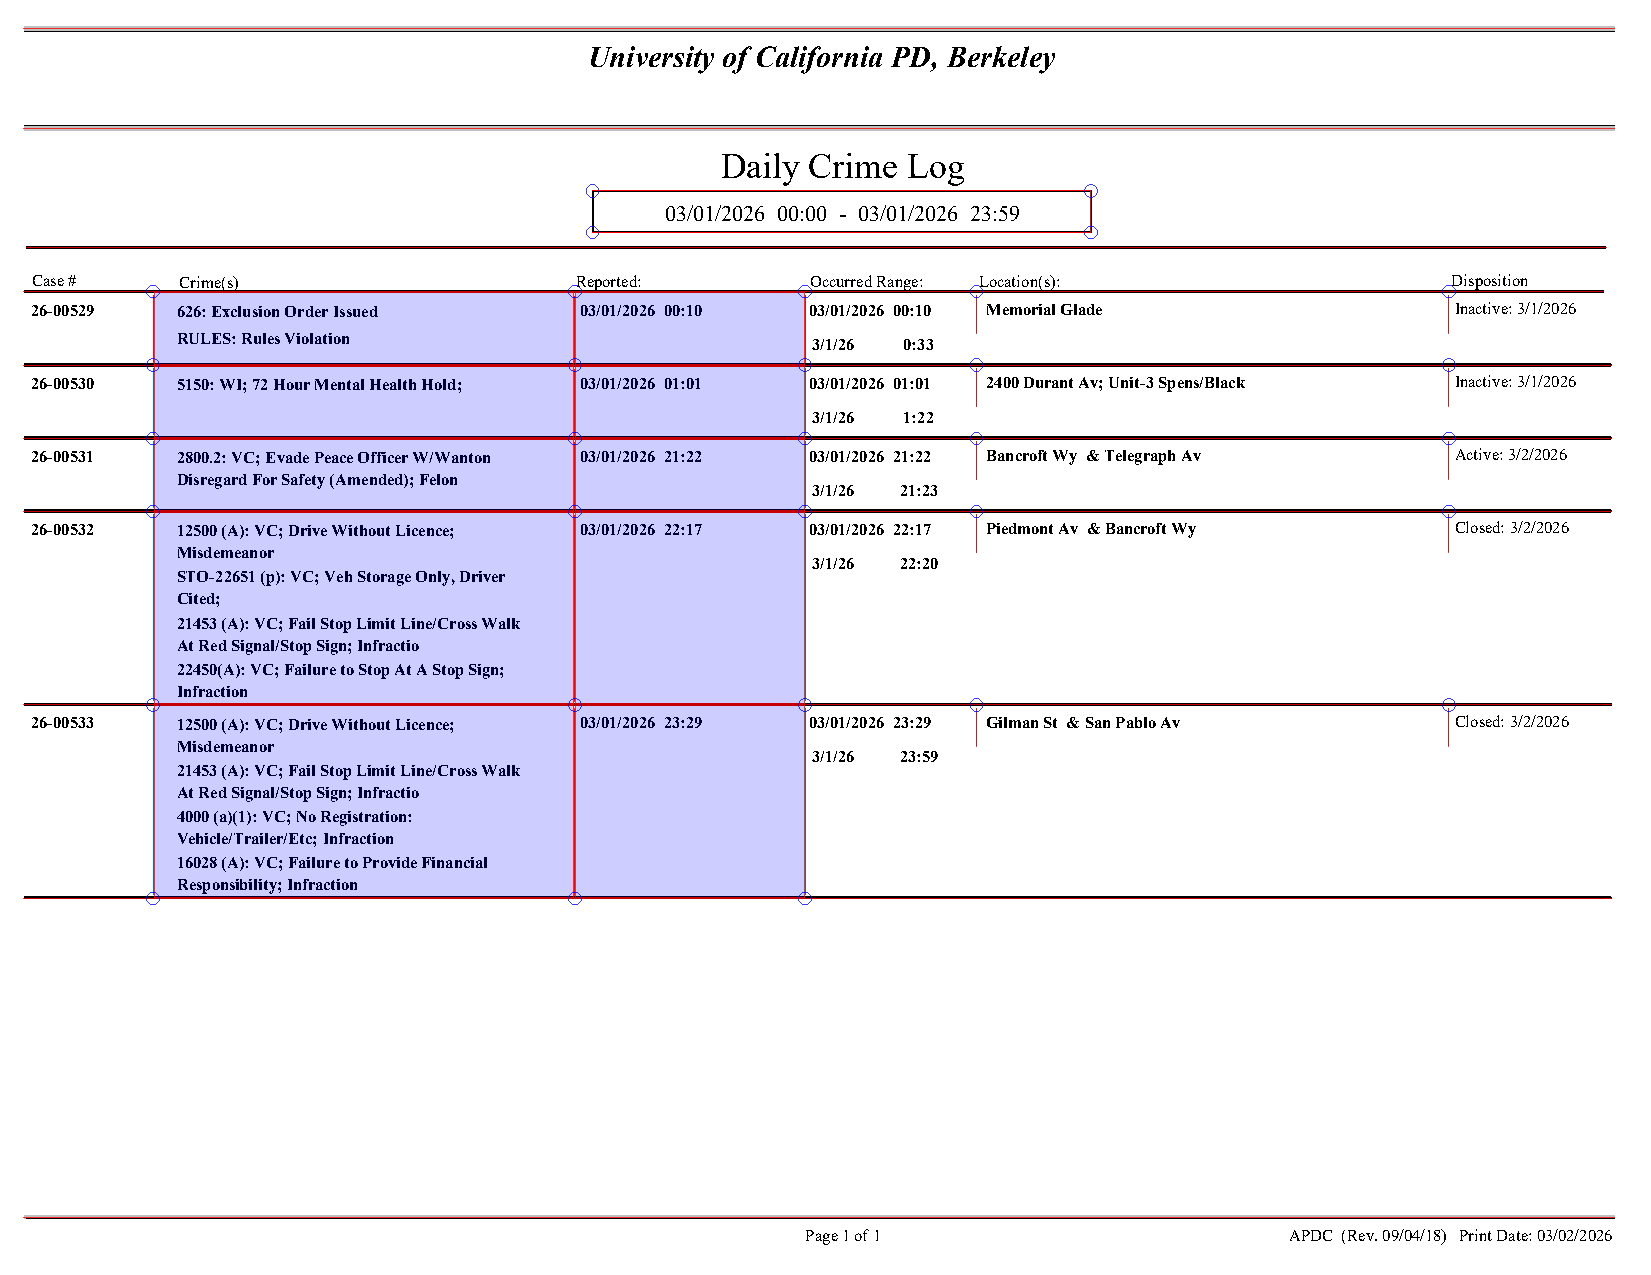

In [18]:
pdf_name = "dcl20260301.pdf"

pdf = pdfplumber.open(pdf_name)
page = pdf.pages[0]
image = page.to_image(resolution=150)
image.reset().debug_tablefinder()

This shows us the auto detect feature of the table structure. Unfortunately, the lines on the table are partially broken and the system isn't able to find the table very well. But we can help it along by cropping the image to just the table portion, and explicitly stating where the vertical lines are in this table. PDF Plumber does the rest.

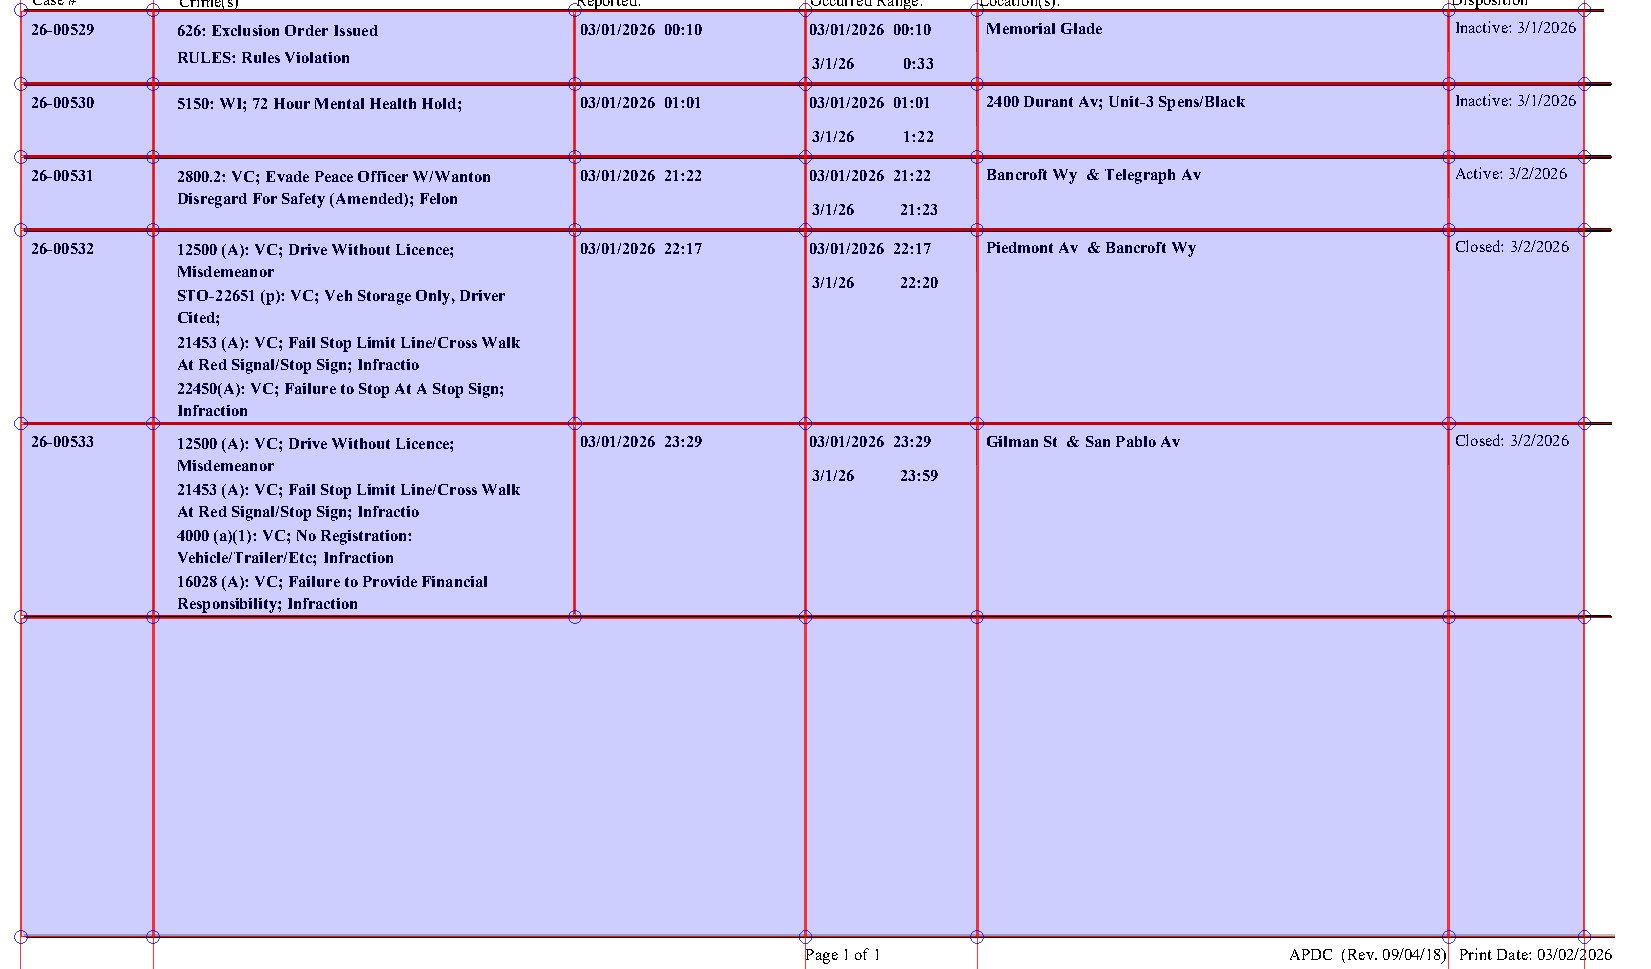

In [19]:
table_settings = {"explicit_vertical_lines":[10, 73, 387, 470, 695, 760]}
crop_settings  = (0, 135,792,600)

image = page.crop(crop_settings).to_image(resolution=150)
image.reset().debug_tablefinder(table_settings)

Much better. Now we can extract the text of the table.

In [20]:
table_text = page.crop(crop_settings).extract_table(table_settings)
table_text

[['26-00529',
  '626: Exclusion Order Issued\nRULES: Rules Violation',
  '03/01/2026 00:10',
  '03/01/2026 00:10\n3/1/26 0:33',
  'Memorial Glade',
  'Inactive: 3/1/2026'],
 ['26-00530',
  '5150: WI; 72 Hour Mental Health Hold;',
  '03/01/2026 01:01',
  '03/01/2026 01:01\n3/1/26 1:22',
  '2400 Durant Av; Unit-3 Spens/Black',
  'Inactive: 3/1/2026'],
 ['26-00531',
  '2800.2: VC; Evade Peace Officer W/Wanton\nDisregard For Safety (Amended); Felon',
  '03/01/2026 21:22',
  '03/01/2026 21:22\n3/1/26 21:23',
  'Bancroft Wy & Telegraph Av',
  'Active: 3/2/2026'],
 ['26-00532',
  '12500 (A): VC; Drive Without Licence;\nMisdemeanor\nSTO-22651 (p): VC; Veh Storage Only, Driver\nCited;\n21453 (A): VC; Fail Stop Limit Line/Cross Walk\nAt Red Signal/Stop Sign; Infractio\n22450(A): VC; Failure to Stop At A Stop Sign;\nInfraction',
  '03/01/2026 22:17',
  '03/01/2026 22:17\n3/1/26 22:20',
  'Piedmont Av & Bancroft Wy',
  'Closed: 3/2/2026'],
 ['26-00533',
  '12500 (A): VC; Drive Without Licence;\nMi

Now that we know we can successfully extract data from a single PDF, let's write a script that takes our settings and goes through every PDF, extracts the table, and then saves it into `table_text` variable.

In [21]:
all_extracted_data = []

downloaded_pdfs_dir = "/content/"

local_pdf_files = [f for f in os.listdir(downloaded_pdfs_dir) if f.endswith('.pdf')]

local_pdf_files.sort()

for pdf_file_name in local_pdf_files:
    full_path = os.path.join(downloaded_pdfs_dir, pdf_file_name)
    try:
        with pdfplumber.open(full_path) as pdf:
            if pdf.pages:
                page = pdf.pages[0]
                extracted_table = page.crop(crop_settings).extract_table(table_settings)

                if extracted_table:
                    all_extracted_data.extend(extracted_table)
                else:
                    print(f"No table extracted from {pdf_file_name} using the specified settings.")
            else:
                print(f"PDF {pdf_file_name} has no pages.")
    except Exception as e:
        print(f"Error processing {pdf_file_name}: {e}")

table_text = all_extracted_data

print(f"Successfully extracted and combined data from {len(local_pdf_files)} PDF files.")
print(f"Total rows in 'table_text': {len(table_text)}")

Successfully extracted and combined data from 3 PDF files.
Total rows in 'table_text': 28


Our data is now in a 2-dimensional Python list (meaning a list where each element is a row, and each inner element is a list of each cell), which is perfect for importing to a Pandas DataFrame. We just need to list the column headers.

In [22]:
columns=["Case", "Crimes", "Reported", "Occurred Range", "Location", "Disposition"]

df = pd.DataFrame(table_text, columns=columns)


df

,Case,Crimes,Reported,Occurred Range,Location,Disposition
0,26-00529,626: Exclusion Order Issued\nRULES: Rules Viol...,03/01/2026 00:10,03/01/2026 00:10\n3/1/26 0:33,Memorial Glade,Inactive: 3/1/2026
1,26-00530,5150: WI; 72 Hour Mental Health Hold;,03/01/2026 01:01,03/01/2026 01:01\n3/1/26 1:22,2400 Durant Av; Unit-3 Spens/Black,Inactive: 3/1/2026
2,26-00531,2800.2: VC; Evade Peace Officer W/Wanton\nDisr...,03/01/2026 21:22,03/01/2026 21:22\n3/1/26 21:23,Bancroft Wy & Telegraph Av,Active: 3/2/2026
3,26-00532,12500 (A): VC; Drive Without Licence;\nMisdeme...,03/01/2026 22:17,03/01/2026 22:17\n3/1/26 22:20,Piedmont Av & Bancroft Wy,Closed: 3/2/2026
4,26-00533,12500 (A): VC; Drive Without Licence;\nMisdeme...,03/01/2026 23:29,03/01/2026 23:29\n3/1/26 23:59,Gilman St & San Pablo Av,Closed: 3/2/2026
5,,,None,,,
6,26-00534,978.5: PC; Bench Warrant/Failure To Appear\nOn...,03/02/2026 03:47,03/02/2026 03:47\n3/2/26 4:00,530 Kinkead Wy; UVA-153,Closed: 3/2/2026
7,26-00535,OA-SEXUAL ASSAULT: Outside Assist\n- Sexual As...,03/02/2026 08:08,02/28/2026 11:30\n2/28/26 14:12,**2300 Block of Piedmont Av,Inactive: 3/2/2026
8,26-00536,*Caslty-Drug Inv: Injury/Illness - Drug Related,03/02/2026 12:45,03/02/2026 12:44\n3/2/26 12:45,Memorial Glade,Inactive: 3/2/2026
9,26-00537,12500 (A): VC; Drive Without Licence;\nMisdeme...,03/02/2026 15:34,03/02/2026 15:34\n3/2/26 15:52,Bancroft Wy & Barrows Ln,Closed: 3/2/2026


Lastly, we can modify out code to create a loop to go through every page of the pdf, and even every pdf file, combining all of the data together into a single spreadsheet. This is beyond the scope of this lesson, so we'll just save this page we extracted.

In [24]:
df.to_csv("first_page_exported.csv", encoding="utf-8", index=False)